# Week 2: Baseline Regression Modeling

## 1. Data Preparation & Feature Encoding
In this phase, we ingest the engineered dataset generated during the Exploratory Data Analysis phase. To prevent target leakage and data type conflicts during scaling, we drop the original `date` column, redundant string columns, and the engineered `High_Load` indicator. Categorical features (`Load_Type` and `day_of_week`) are transformed via One-Hot Encoding to ensure distance-based and linear algorithms do not misinterpret them as ordinal values. The dataset is then split into an 80/20 train-test configuration.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DATA_PATH = os.path.join("data", "Steel_industry_data_engineered.csv")
df = pd.read_csv(DATA_PATH)

# 1. Drop target leakage and redundant columns
cols_to_drop = ['date', 'High_Load', 'WeekStatus', 'Day_of_week']
df_model = df.drop(columns=cols_to_drop, errors='ignore')

# 2. One-Hot Encoding for categorical features
df_encoded = pd.get_dummies(df_model, columns=['Load_Type', 'day_of_week'], drop_first=True)

# 3. Define features (X) and target (y)
X = df_encoded.drop(columns=['Usage_kWh'])
y = df_encoded['Usage_kWh']

# 4. Train-Test Split (80/20 split, random_state=42 for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. Model Training & Evaluation
We establish predictive baselines by training four distinct regression architectures: Linear Regression, Ridge Regression, Decision Tree Regressor, and Random Forest Regressor. Each model is evaluated on the holdout test set using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared ($R^2$). Additionally, 5-fold cross-validation is executed to compute a robust Mean RMSE, ensuring the models are generalizing effectively across different data splits rather than overfitting to the training set.

In [5]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.mean(np.sqrt(-cv_scores))

    results.append({
        "Model": name,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R2": r2,
        "CV Mean RMSE": cv_rmse
    })

results_df = pd.DataFrame(results)
print("--- MODEL EVALUATION METRICS ---")
print(results_df.to_string(index=False))
print("\n" + "="*40)

# Programmatically identify the best model based on Test RMSE
best_idx = results_df['Test RMSE'].idxmin()
best_model_name = results_df.loc[best_idx, 'Model']
best_model_rmse = results_df.loc[best_idx, 'Test RMSE']

print(f"BEST PERFORMING MODEL: {best_model_name}")
print(f"LOWEST TEST RMSE: {best_model_rmse:.4f}")
print("="*40)

--- MODEL EVALUATION METRICS ---
            Model  Test MAE  Test RMSE  Test R2  CV Mean RMSE
Linear Regression  2.613446   4.140520 0.984918      4.603427
 Ridge Regression  2.611097   4.140181 0.984921      4.603432
    Decision Tree  0.535571   1.411955 0.998246      1.541306
    Random Forest  0.350349   1.047135 0.999035      1.135788

BEST PERFORMING MODEL: Random Forest
LOWEST TEST RMSE: 1.0471


## 3. Performance Visualization
To intuitively assess model performance, we visualize the evaluation metrics. A comparative bar chart highlights the Test RMSE across all four models. Subsequently, we generate a scatter plot of Predicted vs. Actual values exclusively for the top-performing model to analyze its predictive variance and identify any heteroscedasticity across the consumption spectrum.

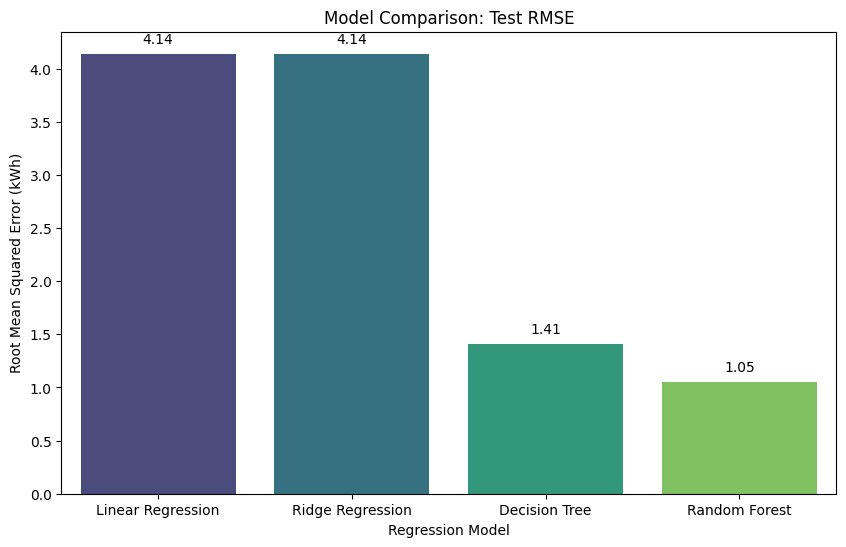

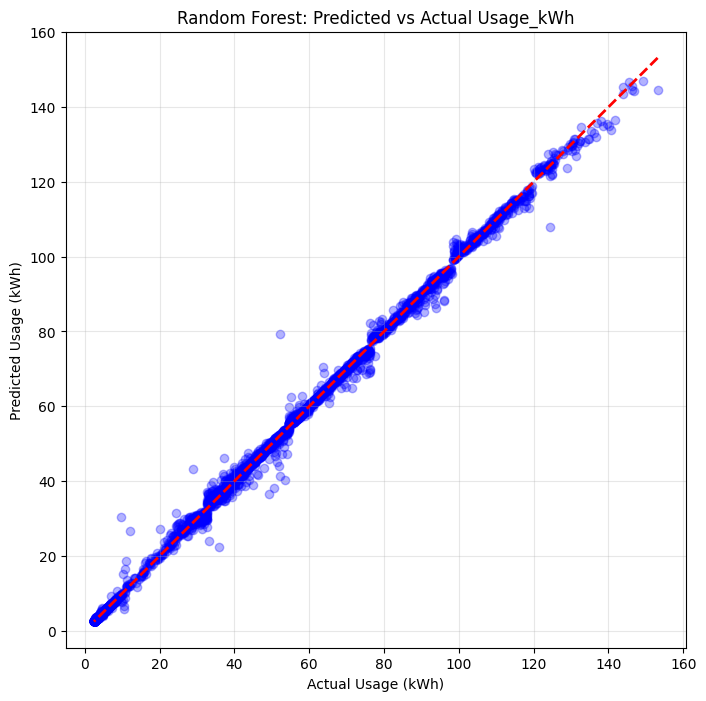

In [6]:

# Bar Chart: Test RMSE Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='Test RMSE', palette='viridis')
plt.title('Model Comparison: Test RMSE')
plt.ylabel('Root Mean Squared Error (kWh)')
plt.xlabel('Regression Model')
for index, row in enumerate(results_df.itertuples()):
    plt.text(index, row._3 + 0.1, f"{row._3:.2f}", color='black', ha="center")
plt.show()

# Scatter Chart: Predicted vs Actual for Best Model
best_model_instance = models[best_model_name]
best_preds = best_model_instance.predict(X_test_scaled)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds, alpha=0.3, color='blue')

# Ideal prediction diagonal line
p1 = max(max(best_preds), max(y_test))
p2 = min(min(best_preds), min(y_test))
plt.plot([p1, p2], [p1, p2], 'r--', lw=2)

plt.title(f'{best_model_name}: Predicted vs Actual Usage_kWh')
plt.xlabel('Actual Usage (kWh)')
plt.ylabel('Predicted Usage (kWh)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()